In [1]:
import joblib
import numpy as np
from dataset import *
from rmap import *
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

## Overall comparison of LP and Baseline's predictions

In [2]:
def get_two_results(target_core_ind):
    """ Retrieves the predicted probabilities for every BB in the 20 bootstrap trials. """
    dir = f"../saved_results/suzuki/{target_core_ind}"
    rmap_results = joblib.load(os.path.join(dir, "rmap_6_rmap.joblib"))
    baseline_results = joblib.load(os.path.join(dir, "rmap_6_baseline.joblib"))
    rfcc_results = joblib.load(os.path.join(dir, "rmap_6_rfc_combined.joblib"))

    all_proba = -1 * np.ones((69, 20, 4)) # 69 BBs, 20 bootstrap trials, 3 models
    for z, result in enumerate([rmap_results, baseline_results, rfcc_results]): 
        for y, t_inds, proba_vals, remaining in zip(
            result["bootstrap_id"], 
            result["train_bb_inds"], 
            result["proba"], 
            result["remaining_inds"]
        ):
            all_proba[[t_inds[x] for x in remaining], y, z] = proba_vals.flatten()
    all_proba[all_proba < 0] = np.nan
    print(all_proba.shape)
    average_proba = np.nanmean(all_proba, axis= 1)

    rmap = ReactivityMap(
        source_core_inds=None,
        target_core_ind=target_core_ind,
        test_bb_inds=[],
        dataset=SuzukiDataset(from_notebook=True)
    )
    actual = rmap.target_reactivity_array

    return average_proba, actual

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


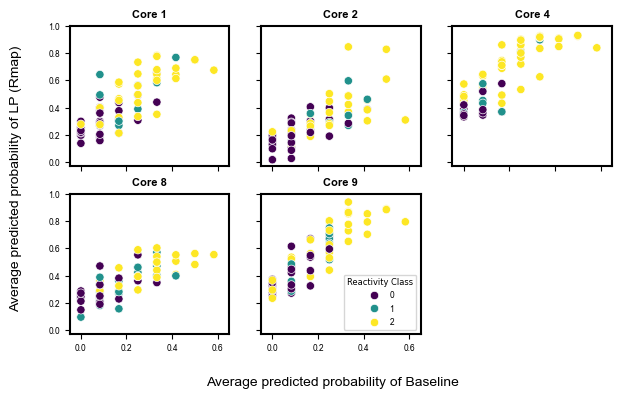

In [3]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(7, 4), sharey=True, sharex=True)

for j, i in enumerate([0, 1, 3, 7, 8]):
    target0_avg_proba, target0_reactivity = get_two_results(i)

    # fig, ax = plt.subplots(figsize=(3,3))
    rmap_vs_baseline_dict = {
        "LP (Rmap)": target0_avg_proba[:, 0],
        "Baseline": target0_avg_proba[:, 1],
        "Actual": target0_reactivity
    }   
    rmap_vs_baseline_df = pd.DataFrame(rmap_vs_baseline_dict).dropna()
    sns.scatterplot(data=rmap_vs_baseline_df, y="LP (Rmap)", x="Baseline", hue="Actual", palette="viridis", ax=ax[j//3, j%3])
    for axis in ["top", "bottom", "left", "right"]:
        ax[j//3, j%3].spines[axis].set_linewidth(1.5)

    ax[j//3, j%3].set_title(f"Core {i+1}", fontsize=8, fontfamily="arial", fontweight="bold")
    ax[j//3, j%3].set_xlim(-0.05, 0.65)
    ax[j//3, j%3].set_xlabel("", fontsize=8, fontfamily="arial")
    ax[j//3, j%3].set_ylabel("", fontsize=8, fontfamily="arial")
    ax[j//3, j%3].set_yticks([round(x, 1) for x in np.arange(0, 1.1, 0.2)])
    ax[j//3, j%3].set_yticklabels([round(x, 1) for x in np.arange(0, 1.1, 0.2)], fontsize=6, fontfamily="arial")
    ax[j//3, j%3].set_xticks([0, 0.2, 0.4, 0.6])
    ax[j//3, j%3].set_xticklabels(["0.0"]+[round(x, 1) for x in np.arange(0.2, 0.65, 0.2)], fontsize=6, fontfamily="arial")
    if j == 4 :
        ax[j//3, j%3].legend(title="Reactivity Class", prop=fm.FontProperties(family="Arial", size=6), title_fontsize=6, loc="lower right")
    else :
        ax[j//3, j%3].get_legend().remove()
    for axis in ["top", "bottom", "left", "right"]:
        ax[j//3, j%3].spines[axis].set_linewidth(1.5)
    
for loc in ["top", "right", "bottom", "left"]:
    ax[1, 2].spines[loc].set_visible(False)
    ax[1, 2].xaxis.set_visible(False)
    ax[1, 2].yaxis.set_visible(False)
fig.text(0.04, 0.5, "Average predicted probability of LP (Rmap)", fontsize=10, fontfamily="arial", rotation="vertical", va="center")
fig.text(0.5, -0.02, "Average predicted probability of Baseline", fontsize=10, fontfamily="arial", ha="center")
plt.savefig(f"../figures/eval_second/FigureS25.svg", dpi=300, bbox_inches="tight", format="svg")

## Looking at specific BB examples for core 1

In [4]:
target0_avg_proba, target0_reactivity = get_two_results(0)
rmap_vs_baseline_dict = {
    "LP (Rmap)": target0_avg_proba[:, 0],
    "Baseline": target0_avg_proba[:, 1],
    "Actual": target0_reactivity
}   
rmap_vs_baseline_df = pd.DataFrame(rmap_vs_baseline_dict).dropna()

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


### Example of LP successfully deprioritizing low-yielding while baseline fails

In [5]:
rmap_vs_baseline_df[(rmap_vs_baseline_df["Baseline"] > 0.3) & (rmap_vs_baseline_df["LP (Rmap)"] < 0.5)]

,LP (Rmap),Baseline,Actual
14,0.441050,0.333333,0
15,0.351843,0.333333,2


In [6]:
rmap0 = ReactivityMap(
    source_core_inds=None,
    target_core_ind=0,
    test_bb_inds=[],
    dataset=SuzukiDataset(from_notebook=True)
)
rmap0.dataset.yield_array[0, 14] # The first row in the output of the cell above

11.539255518513215

In [7]:
rmap0.dataset.bb_smiles[14]

'OB(O)c1cccc(OCc2ccccc2)c1'

In [8]:
# There are 7 BBs ranked above this particular BB by the baseline
print(rmap_vs_baseline_df[rmap_vs_baseline_df["Baseline"] > 1/3].shape)
# LP ranks it at 30th place
print(rmap_vs_baseline_df[rmap_vs_baseline_df["LP (Rmap)"] > 0.441050].shape)

(8, 3)
(29, 3)


### Example of LP successfully prioritizing high-yielding while baseline fails

In [9]:
rmap_vs_baseline_df[(rmap_vs_baseline_df["Baseline"] < 0.3) & (rmap_vs_baseline_df["LP (Rmap)"] > 0.7)]

,LP (Rmap),Baseline,Actual
33,0.734533,0.25,2


In [10]:
rmap0.dataset.yield_array[0, 33]

63.26647761841554

In [11]:
rmap0.dataset.bb_smiles[33]

'OCc1cccc(B(O)O)c1'

In [12]:
# There are 17 BBs ranked above this particular BB by the baseline
print(rmap_vs_baseline_df[rmap_vs_baseline_df["Baseline"] > 0.25].shape)
# There are 10 BBs tied as ranked by the baseline
print(rmap_vs_baseline_df[rmap_vs_baseline_df["Baseline"] == 0.25].shape)
# LP ranks it at 6th place
print(rmap_vs_baseline_df[rmap_vs_baseline_df["LP (Rmap)"] > 0.734533].shape)

(17, 3)
(10, 3)
(5, 3)


## Looking at specific BB examples for core 2

In [13]:
target2_avg_proba, target2_reactivity = get_two_results(1)
rmap_vs_baseline_dict2 = {
    "LP (Rmap)": target2_avg_proba[:, 0],
    "Baseline": target2_avg_proba[:, 1],
    "Actual": target2_reactivity
}   
rmap_vs_baseline_df2 = pd.DataFrame(rmap_vs_baseline_dict2).dropna()

(69, 20, 4)


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_87987/3215184636.py:19: RuntimeWarning: Mean of empty slice
  average_proba = np.nanmean(all_proba, axis= 1)


In [14]:
rmap_vs_baseline_df2[(rmap_vs_baseline_df2["Baseline"] > 0.3) & (rmap_vs_baseline_df2["LP (Rmap)"] < 0.4) & (rmap_vs_baseline_df2["Actual"] < 2)]

,LP (Rmap),Baseline,Actual
1,0.270111,0.333333,1
14,0.285710,0.333333,0
15,0.388557,0.416667,0
67,0.343438,0.333333,1


In [15]:
# There are 10 BBs ranked above this particular BB by the baseline
print(rmap_vs_baseline_df2[rmap_vs_baseline_df2["Baseline"] > 1/3].shape)
# LP ranks it at 33rd place
print(rmap_vs_baseline_df2[rmap_vs_baseline_df2["LP (Rmap)"] > 0.28571].shape)

(10, 3)
(32, 3)


In [16]:
rmap_vs_baseline_df2[(rmap_vs_baseline_df2["Baseline"] < 0.3) & (rmap_vs_baseline_df2["LP (Rmap)"] > 0.4) & (rmap_vs_baseline_df2["Actual"] == 2)]

,LP (Rmap),Baseline,Actual
32,0.446867,0.25,2
33,0.503335,0.25,2


In [ ]:
# There are 18 BBs ranked above this particular BB by the baseline
print(rmap_vs_baseline_df2[rmap_vs_baseline_df2["Baseline"] > 0.25].shape)
# There are 10 BBs tied as ranked by the baseline
print(rmap_vs_baseline_df2[rmap_vs_baseline_df2["Baseline"] == 0.25].shape)
# LP ranks it at 5th place
print(rmap_vs_baseline_df2[rmap_vs_baseline_df2["LP (Rmap)"] > 0.504].shape)

(18, 3)
(10, 3)
(4, 3)
